# EJERCICIO FINAL PYSPARK (DOCKER + KAFKA + PYSPARK)

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *
from pyspark.sql import functions as F
from pyspark.sql.window import Window


## Creamos la sesión de spark

In [3]:
spark = (
    SparkSession.builder
        .appName("ProyectoIoT")
        .getOrCreate()
)
spark

spark.readStream
Indica que vamos a leer datos en modo streaming, es decir, datos que llegan continuamente.

.format("kafka")
Le decimos a Spark que la fuente de datos de streaming será Kafka.

.option("kafka.bootstrap.servers", "kafka:9092")
Especifica la dirección del clúster Kafka al que conectarse.
En este caso "kafka" es el nombre del contenedor Docker y 9092 es el puerto del broker.

.option("subscribe", "sensores")
Indica el topic de Kafka del que queremos leer mensajes → "sensores".

.option("startingOffsets", "latest")
Define desde qué punto empezar a leer:

"latest" → solo recibe mensajes nuevos, enviados después de iniciar el streaming.

"earliest" sería para leer todos los mensajes antiguos también.

.load()
Ejecuta la configuración y crea un DataFrame de streaming, donde cada fila representa un mensaje recibido desde Kafka.

In [4]:
raw_df = (
    spark.readStream
         .format("kafka")
         .option("kafka.bootstrap.servers", "kafka:9092")  # <-- nombre del contenedor
         .option("subscribe", "sensores")
         .option("startingOffsets", "latest")
         .load()
)


Este bloque transforma los mensajes de Kafka en un formato que Spark puede procesar:

Define la estructura de los datos que esperamos recibir (sensor, valor, temperatura, humedad, estado, timestamp y UUID).

Convierte el JSON recibido en columnas individuales para poder trabajar con cada campo.

Crea una columna de tiempo (event_time) a partir del timestamp original para poder usarlo en ventanas y agregaciones temporales.

In [5]:
schema = StructType([
    StructField("sensor_id", StringType()),
    StructField("value", DoubleType()),
    StructField("temperature", DoubleType()),
    StructField("humidity", DoubleType()),
    StructField("status", StringType()),
    StructField("timestamp", DoubleType()),
    StructField("uuid", StringType())
])

df = raw_df.select(
    from_json(col("value").cast("string"), schema).alias("data")
).select("data.*")

df = df.withColumn("event_time", col("timestamp").cast("timestamp"))


Este bloque realiza agregaciones por ventana de tiempo sobre el DataFrame de streaming:

Define un watermark de 1 minuto para indicar a Spark hasta qué punto los datos antiguos se pueden considerar válidos. Esto ayuda a manejar retrasos y datos tardíos.

Agrupa los datos cada 30 segundos por sensor (sensor_id).

Calcula estadísticas dentro de cada ventana: promedio de valor, temperatura y humedad, y cuenta el número de eventos recibidos.

El resultado es un DataFrame de streaming con resúmenes temporales por sensor listo para análisis o escritura.

In [6]:
agg_df = (
    df
    .withWatermark("event_time", "1 minute")   # ← IMPORTANTE
    .groupBy(
        window(col("event_time"), "30 seconds"),
        col("sensor_id")
    )
    .agg(
        avg("value").alias("avg_value"),
        avg("temperature").alias("avg_temp"),
        avg("humidity").alias("avg_humidity"),
        count("*").alias("num_events")
    )
)


Este bloque escribe los resultados del streaming en archivos Parquet de manera continua:

Define la carpeta de salida donde se guardarán los archivos Parquet (resultados/).

Usa un checkpoint (chk/) para que Spark recuerde qué datos ya procesó y pueda reiniciar de forma segura en caso de fallo.

Modo append: los nuevos datos se agregan continuamente a los archivos existentes.

Inicia el streaming, haciendo que las agregaciones se escriban en tiempo real mientras llegan nuevos datos.

El resultado es un conjunto de archivos Parquet que refleja las métricas agregadas por ventana y por sensor.

In [15]:
parquet_query = (
    agg_df
    .writeStream
    .format("parquet")
    .option("path", "resultados/")
    .option("checkpointLocation", "chk/")
    .outputMode("append")
    .start()
)


A partir de aquí, te toca a ti, sigue las cuestiones planteadas en el Readme y completa el notebook. Despues guardatelo con los outputs de las celdas y súbelo al repo. Mucha suerte que ya lo teneis ;)

### Ejercicio 1

In [19]:
agg_df.printSchema()

root
 |-- window: struct (nullable = false)
 |    |-- start: timestamp (nullable = true)
 |    |-- end: timestamp (nullable = true)
 |-- sensor_id: string (nullable = true)
 |-- avg_value: double (nullable = true)
 |-- avg_temp: double (nullable = true)
 |-- avg_humidity: double (nullable = true)
 |-- num_events: long (nullable = false)



In [20]:
resultados_df = spark.read.parquet("resultados/")
resultados_df.count()

20

In [21]:
resultados_df.select(countDistinct("sensor_id")).show()

+-------------------------+
|count(DISTINCT sensor_id)|
+-------------------------+
|                        4|
+-------------------------+



### Ejercicio 2

In [24]:
dif_Met = resultados_df.withColumn("dif_Met", coalesce(col("avg_humidity"), lit(0)) - coalesce(col("avg_temp"), lit(0)))
dif_Met.show(3)                                                                                              

+--------------------+---------+------------------+-----------------+------------------+----------+-------------------+
|              window|sensor_id|         avg_value|         avg_temp|      avg_humidity|num_events|            dif_Met|
+--------------------+---------+------------------+-----------------+------------------+----------+-------------------+
|{2025-12-15 10:04...|       S4|26.389999999999997|           61.972|            59.218|         5| -2.753999999999998|
|{2025-12-15 10:04...|       S3|43.292500000000004|          41.2225|49.010000000000005|         4| 7.7875000000000085|
|{2025-12-15 10:04...|       S1|30.281666666666666|56.52833333333333| 55.46666666666666|         6|-1.0616666666666674|
+--------------------+---------+------------------+-----------------+------------------+----------+-------------------+
only showing top 3 rows



In [25]:
dif_Met.select(
    min("dif_Met").alias("minimo"),
    max("dif_Met").alias("maximo"),
    mean("dif_Met").alias("media")).show()

+------------------+------------------+------------------+
|            minimo|            maximo|             media|
+------------------+------------------+------------------+
|-21.33666666666668|24.416250000000005|-1.979849999999999|
+------------------+------------------+------------------+



### Ejercicio 3

In [26]:
df_filtrado = resultados_df.filter(
    (col("avg_humidity") > 30) &
    (col("num_events") > 1) &
    (col("sensor_id").isNotNull())
)
df_filtrado.show(5)
df_filtrado.count()

+--------------------+---------+------------------+-----------------+------------------+----------+
|              window|sensor_id|         avg_value|         avg_temp|      avg_humidity|num_events|
+--------------------+---------+------------------+-----------------+------------------+----------+
|{2025-12-15 10:04...|       S4|26.389999999999997|           61.972|            59.218|         5|
|{2025-12-15 10:04...|       S3|43.292500000000004|          41.2225|49.010000000000005|         4|
|{2025-12-15 10:04...|       S1|30.281666666666666|56.52833333333333| 55.46666666666666|         6|
|{2025-12-15 10:05...|       S3|25.808000000000003|           52.754|            59.114|        10|
|{2025-12-15 10:05...|       S1|26.877499999999998|         70.38125|           57.3275|         8|
+--------------------+---------+------------------+-----------------+------------------+----------+
only showing top 5 rows



20

### Ejercicio 4

In [29]:
df_stats = resultados_df.groupBy("sensor_id").agg(
    avg("avg_value").alias("media_valor"),
    max("avg_temp").alias("temp_maxima"),
    count("*").alias("total_ventanas")
)
df_stats.show()


+---------+------------------+-----------------+--------------+
|sensor_id|       media_valor|      temp_maxima|total_ventanas|
+---------+------------------+-----------------+--------------+
|       S4| 32.22879999999999|67.86833333333334|             5|
|       S3|32.755100000000006|60.77666666666667|             5|
|       S2|31.261333333333333|            62.85|             5|
|       S1|30.574666666666666|         70.38125|             5|
+---------+------------------+-----------------+--------------+



In [30]:
df_stats.orderBy(col("media_valor").desc()).show(1)
df_stats.orderBy(col("temp_maxima").desc()).show(1)

+---------+------------------+-----------------+--------------+
|sensor_id|       media_valor|      temp_maxima|total_ventanas|
+---------+------------------+-----------------+--------------+
|       S3|32.755100000000006|60.77666666666667|             5|
+---------+------------------+-----------------+--------------+
only showing top 1 row

+---------+------------------+-----------+--------------+
|sensor_id|       media_valor|temp_maxima|total_ventanas|
+---------+------------------+-----------+--------------+
|       S1|30.574666666666666|   70.38125|             5|
+---------+------------------+-----------+--------------+
only showing top 1 row



### Ejercicio 5

In [31]:
ventana = Window.partitionBy("sensor_id").orderBy(col("avg_value").desc())

# Añadimos el ranking
ranking_df = resultados_df.withColumn("ranking", row_number().over(ventana))

# Filto de solo los número 1 x senor
max_x_sensor = ranking_df.filter(col("ranking") == 1)
max_x_sensor.show()

print("El sensor que obtiene el valor máximo global de avg_value es:")
max_x_sensor.orderBy(col("avg_value").desc()).show(1)

+--------------------+---------+------------------+------------------+------------------+----------+-------+
|              window|sensor_id|         avg_value|          avg_temp|      avg_humidity|num_events|ranking|
+--------------------+---------+------------------+------------------+------------------+----------+-------+
|{2025-12-15 10:06...|       S1| 33.46666666666667|            57.345|57.004999999999995|         6|      1|
|{2025-12-15 10:04...|       S2| 39.32666666666667|46.288333333333334| 61.60833333333334|         6|      1|
|{2025-12-15 10:04...|       S3|43.292500000000004|           41.2225|49.010000000000005|         4|      1|
|{2025-12-15 10:05...|       S4|             34.76|58.771249999999995|          51.34875|         8|      1|
+--------------------+---------+------------------+------------------+------------------+----------+-------+

El sensor que obtiene el valor máximo global de avg_value es:
+--------------------+---------+------------------+--------+-----

### Ejercicio 6

In [ ]:

data_sensores = [
    Row(sensor_id="S1", ubicacion="Laboratorio", tipo="Interior"),
    Row(sensor_id="S2", ubicacion="Almacen",     tipo="Interior"),
    Row(sensor_id="S3", ubicacion="Exterior",    tipo="Ambiente"),
    Row(sensor_id="S4", ubicacion="Oficina",     tipo="Interior")
]
data_sensores_df = spark.createDataFrame(data_sensores)
data_sensores_df.show()


df_unido = resultados_df.join(data_sensores_df, "sensor_id", "left")

print("Muestra los cinco primeros registros del DataFrame ya unido")
df_unido.show(5)

+---------+-----------+--------+
|sensor_id|  ubicacion|    tipo|
+---------+-----------+--------+
|       S1|Laboratorio|Interior|
|       S2|    Almacen|Interior|
|       S3|   Exterior|Ambiente|
|       S4|    Oficina|Interior|
+---------+-----------+--------+

Muestra los cinco primeros registros del DataFrame ya unido
+---------+--------------------+------------------+-----------------+------------------+----------+-----------+--------+
|sensor_id|              window|         avg_value|         avg_temp|      avg_humidity|num_events|  ubicacion|    tipo|
+---------+--------------------+------------------+-----------------+------------------+----------+-----------+--------+
|       S4|{2025-12-15 10:04...|26.389999999999997|           61.972|            59.218|         5|    Oficina|Interior|
|       S4|{2025-12-15 10:05...|            33.855|67.86833333333334| 47.43833333333333|         6|    Oficina|Interior|
|       S3|{2025-12-15 10:04...|43.292500000000004|          41.2225|4

### Ejercicio 7

In [34]:


print("Agrupación por ventana temporal")

# 1. Extraemos el inicio de la ventana y lo truncamos a minutos
df_tiempo = resultados_df.withColumn("minuto", date_trunc("minute", col("window.start")))

# 2. Agrupamos
df_agrupado = df_tiempo.groupBy("minuto").agg(
    count("*").alias("num_ventanas"),
    avg("avg_humidity").alias("humedad_media")
)

df_agrupado.orderBy("minuto").show(5, truncate=False)

Agrupación por ventana temporal
+-------------------+------------+-----------------+
|minuto             |num_ventanas|humedad_media    |
+-------------------+------------+-----------------+
|2025-12-15 10:04:00|8           |57.80719791666667|
|2025-12-15 10:05:00|8           |56.14992708333334|
|2025-12-15 10:06:00|4           |53.3923125       |
+-------------------+------------+-----------------+



### Ejercicio 8

In [35]:
df_repartido = resultados_df.repartition(4, "sensor_id")

# 2. Añadimos una columna para ver en qué ID de partición cayó cada dato
df_particiones = df_repartido.withColumn("partition_id", spark_partition_id())

# 3. Contamos cuántos datos hay en cada partición
df_particiones.groupBy("partition_id").count().show()

+------------+-----+
|partition_id|count|
+------------+-----+
|           0|    5|
|           1|   10|
|           3|    5|
+------------+-----+



### Ejercicio 9

In [36]:
# 1. Calculamos la media y desviación estándar global
stats = resultados_df.select(
    mean("avg_value").alias("media"),
    stddev("avg_value").alias("desv")
).collect()[0]

# Definimos límites: Lo que se aleje más de 2 desviaciones es una anomalía
limite_sup = stats["media"] + (2 * stats["desv"])
limite_inf = stats["media"] - (2 * stats["desv"])

print(f"Rango normal: entre {limite_sup:.2f} y {limite_inf:.2f}")

# 2. Marcamos las anomalías
df_anomalias = resultados_df.withColumn(
    "es_anomalo",
    (col("avg_value") > limite_sup) | (col("avg_value") < limite_inf)
)
df_anomalias.show(5)

print(f"Total de registros anómalos: {df_anomalias.filter(col('es_anomalo')).count()}")

print("Sensor con más anomalías")
df_anomalias.filter(col("es_anomalo")).groupBy("sensor_id").count().orderBy(desc("count")).show(1)

Rango normal: entre 41.22 y 22.19
+--------------------+---------+------------------+-----------------+------------------+----------+----------+
|              window|sensor_id|         avg_value|         avg_temp|      avg_humidity|num_events|es_anomalo|
+--------------------+---------+------------------+-----------------+------------------+----------+----------+
|{2025-12-15 10:04...|       S4|26.389999999999997|           61.972|            59.218|         5|     false|
|{2025-12-15 10:04...|       S3|43.292500000000004|          41.2225|49.010000000000005|         4|      true|
|{2025-12-15 10:04...|       S1|30.281666666666666|56.52833333333333| 55.46666666666666|         6|     false|
|{2025-12-15 10:05...|       S3|25.808000000000003|           52.754|            59.114|        10|     false|
|{2025-12-15 10:05...|       S1|26.877499999999998|         70.38125|           57.3275|         8|     false|
+--------------------+---------+------------------+-----------------+---------

### Ejercicio 10

In [38]:
print("Cruce de metricas")

df_score = resultados_df.withColumn(
    "score",
    (col("avg_value") * 0.6) + (col("avg_temp") * 0.2) + (col("avg_humidity") * 0.2)
)

df_score.select("sensor_id", "avg_value", "avg_temp", "avg_humidity", "score").show(5)

print("Sensor con la puntuación media más alta")
df_score.groupBy("sensor_id") \
    .agg(mean("score").alias("score_medio")) \
    .orderBy(desc("score_medio")) \
    .show(1)

Cruce de metricas
+---------+------------------+-----------------+------------------+-----------------+
|sensor_id|         avg_value|         avg_temp|      avg_humidity|            score|
+---------+------------------+-----------------+------------------+-----------------+
|       S4|26.389999999999997|           61.972|            59.218|           40.072|
|       S3|43.292500000000004|          41.2225|49.010000000000005|           44.022|
|       S1|30.281666666666666|56.52833333333333| 55.46666666666666|           40.568|
|       S3|25.808000000000003|           52.754|            59.114|          37.8584|
|       S1|26.877499999999998|         70.38125|           57.3275|41.66824999999999|
+---------+------------------+-----------------+------------------+-----------------+
only showing top 5 rows

Sensor con la puntuación media más alta
+---------+-----------------+
|sensor_id|      score_medio|
+---------+-----------------+
|       S1|42.79171666666666|
+---------+------------

### Ejercicio 11

Generando Gráficos


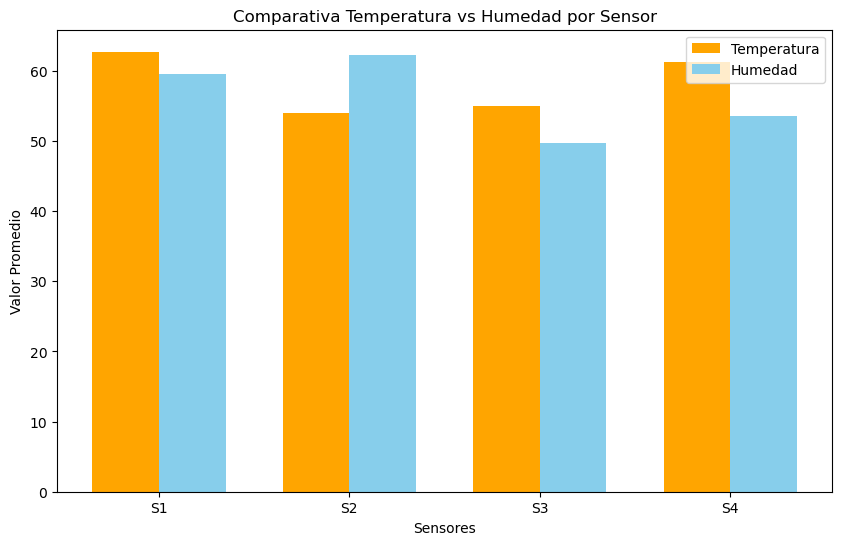

In [40]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("Generando Gráficos")

# 1. Convertimos a Pandas (solo las columnas necesarias)
pdf = resultados_df.select("sensor_id", "avg_temp", "avg_humidity").toPandas()

# 2. Agrupamos por sensor
pdf_resumen = pdf.groupby("sensor_id").mean().reset_index()

# Gráfico
# Definimos posiciones para las barras
x = np.arange(len(pdf_resumen["sensor_id"]))
ancho = 0.35

plt.figure(figsize=(10, 6))

# Dibujamos dos barras: Temperatura y Humedad
plt.bar(x - ancho/2, pdf_resumen["avg_temp"], ancho, label='Temperatura', color='orange')
plt.bar(x + ancho/2, pdf_resumen["avg_humidity"], ancho, label='Humedad', color='skyblue')

# Etiquetas y títulos
plt.xlabel('Sensores')
plt.ylabel('Valor Promedio')
plt.title('Comparativa Temperatura vs Humedad por Sensor')
plt.xticks(x, pdf_resumen["sensor_id"])
plt.legend()

plt.show()

Generando Gráfico Comparativo


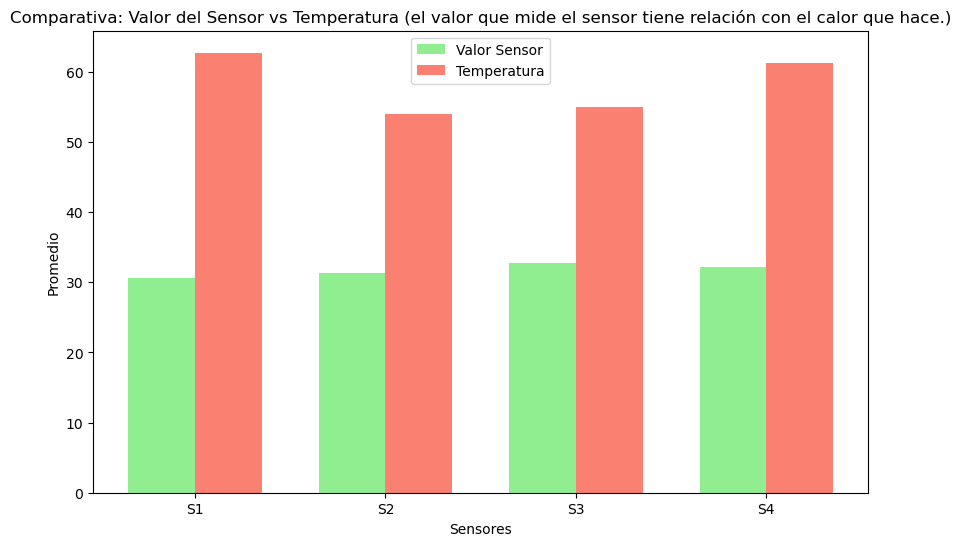

In [39]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("Generando Gráfico Comparativo")

# 1. Convertimos a Pandas
pdf = resultados_df.select("sensor_id", "avg_value", "avg_temp").toPandas()

# 2. Agrupamos por sensor
pdf_resumen = pdf.groupby("sensor_id").mean().reset_index()

# Configuración del gráfico
x = np.arange(len(pdf_resumen["sensor_id"]))
ancho = 0.35

plt.figure(figsize=(10, 6))

# Dibujamos las dos barras Valor Promedio (en verde) y Temperatura (en rojo suave)

plt.bar(x - ancho/2, pdf_resumen["avg_value"], ancho, label='Valor Sensor', color='lightgreen')
plt.bar(x + ancho/2, pdf_resumen["avg_temp"], ancho, label='Temperatura', color='salmon')

# Etiquetas y títulos 
plt.xlabel('Sensores')
plt.ylabel('Promedio')
plt.title('Comparativa: Valor del Sensor vs Temperatura (el valor que mide el sensor tiene relación con el calor que hace.)')
plt.xticks(x, pdf_resumen["sensor_id"])
plt.legend()

plt.show()